# Part 2: MobileNetV3-Small Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [ ]:
from pathlib import Path
import importlib
import os
import sys


In [ ]:
from pathlib import Path
import importlib
import importlib.util

_REQUIRED_PROJECT_FILES = (
    Path('src/__init__.py'),
    Path('src/utils/notebook_setup.py'),
    Path('src/evaluation/experiment_results.py'),
)

_CANDIDATE_PROJECT_ROOTS = (
    Path('/content/drive/MyDrive/MLDS_Final_Project'),
    Path('/content/MLDS_Final_Project'),
    Path('/content/drive/MyDrive/Colab Notebooks/MLDS_Final_Project'),
)


def _safe_resolve(path):
    try:
        return Path(path).resolve()
    except OSError:
        return None


def _safe_exists(path):
    try:
        return Path(path).exists()
    except OSError:
        return False


def _safe_cwd():
    try:
        return Path.cwd().resolve()
    except OSError:
        fallback = Path('/content')
        return fallback if _safe_exists(fallback) else Path.home()


def _safe_glob(path, pattern):
    try:
        return list(path.glob(pattern))
    except OSError:
        return []


def _path_looks_like_project_root(path):
    try:
        return all((path / required).is_file() for required in _REQUIRED_PROJECT_FILES)
    except OSError:
        return False


def _candidate_project_roots():
    current = _safe_cwd()
    candidates = [current, *current.parents, *_CANDIDATE_PROJECT_ROOTS]
    my_drive = Path('/content/drive/MyDrive')
    if _safe_exists(my_drive):
        candidates.extend(_safe_glob(my_drive, 'MLDS_Final_Project'))
        candidates.extend(_safe_glob(my_drive, '*/MLDS_Final_Project'))
    return candidates


def _find_project_root():
    seen = set()
    for candidate in _candidate_project_roots():
        candidate = _safe_resolve(candidate)
        if candidate is None or candidate in seen:
            continue
        seen.add(candidate)
        if _path_looks_like_project_root(candidate):
            return candidate
    return None


def _mount_colab_drive_if_available():
    try:
        from google.colab import drive  # type: ignore
    except ImportError:
        return
    drive.mount('/content/drive', force_remount=True)


_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT is None:
    _mount_colab_drive_if_available()
    _PROJECT_ROOT = _find_project_root()

if _PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        'Could not find the full MLDS_Final_Project repo. Expected '
        'src/__init__.py, src/utils/notebook_setup.py, and '
        'src/evaluation/experiment_results.py. In Colab, upload or clone '
        'the full repo, or place it at /content/drive/MyDrive/MLDS_Final_Project.'
    )

_COLAB_UTILS_PATH = _PROJECT_ROOT / 'src' / 'utils' / 'colab.py'
_COLAB_SPEC = importlib.util.spec_from_file_location('_mlds_colab_bootstrap', _COLAB_UTILS_PATH)
if _COLAB_SPEC is None or _COLAB_SPEC.loader is None:
    raise ImportError(f'Could not load Colab bootstrap helpers from {_COLAB_UTILS_PATH}')
_colab_bootstrap = importlib.util.module_from_spec(_COLAB_SPEC)
_COLAB_SPEC.loader.exec_module(_colab_bootstrap)

ROOT = _colab_bootstrap.bootstrap_notebook_runtime(_PROJECT_ROOT, force_remount=False)
notebook_setup = importlib.import_module('src.utils.notebook_setup')
ROOT


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python: 3.12.13
Package versions:
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.16.3
  scikit-learn: 1.6.1
  torch: 2.11.0+cu128
  torchvision: 0.26.0+cu128
  timm: 1.0.27
  pyyaml: 6.0.3
torch.cuda.is_available(): True
CUDA device: NVIDIA L4
Project root: /content/drive/MyDrive/MLDS_Final_Project


PosixPath('/content/drive/MyDrive/MLDS_Final_Project')

In [ ]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)


In [ ]:
import src.experiments.part2 as part2_experiments
import src.experiments.enhanced_confidence as enhanced_confidence

part2_experiments = importlib.reload(part2_experiments)
enhanced_confidence = importlib.reload(enhanced_confidence)
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
stage_configured_colab_data_dir = experiment_results.stage_configured_colab_data_dir
run_part2_improvement_experiments = part2_experiments.run_part2_improvement_experiments
run_part2_enhanced_confidence_experiment = enhanced_confidence.run_part2_enhanced_confidence_experiment
enhanced_confidence_output_paths = enhanced_confidence.enhanced_confidence_output_paths


## Configuration

In [ ]:
part2_setup = notebook_setup.setup_part2_config()
config = part2_setup.config
config.stage_colab_data_to_local_disk = True  # Set False on Colab to read directly from Drive instead of copying to /content.
part2_setup.summary['stage_colab_data_to_local_disk'] = config.stage_colab_data_to_local_disk
part2_setup.summary['colab_local_data_dir'] = config.colab_local_data_dir
device = part2_setup.device
output_paths = part2_setup.output_paths
part2_setup.summary


Running on Google Colab, adjusting configs...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selected device: cuda
Python: 3.12.13
Package versions:
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.16.3
  scikit-learn: 1.6.1
  torch: 2.11.0+cu128
  torchvision: 0.26.0+cu128
  timm: 1.0.27
  pyyaml: 6.0.3
torch.cuda.is_available(): True
CUDA device: NVIDIA L4
Selected device: cuda


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,tile_permutation_names,grid_x_permutation_runs,epochs,batch_size,num_workers,use_amp,stage_colab_data_to_local_disk,colab_local_data_dir,device
0,part2,part2_improvement,resnet18,"[1, 4, 7, 10]",3,"[easy, medium, hard]",12,10,64,4,True,True,/content/MLDS_Final_Project/data/dogs-vs-cats/...,cuda


In [ ]:
print(config)


Part2ExperimentConfig(part='part2', config_name='part2_improvement', device='auto', deterministic=False, root_dir='/content/drive/MyDrive/MLDS_Final_Project', data_dir='/content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs', results_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs/results', figures_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs/figures', sample_data=False, sample_limit=256, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=64, num_workers=4, num_classes=2, model_names=['resnet18'], pretrained=True, freeze_backbone=True, tiles_per_side_values=[1, 4, 7, 10], num_tile_permutations=3, epochs=10, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=True, seed=42, max_threads=4, using_google_colab=True, plot_samples=False, stage_colab_data_to_local_disk=True, colab_local_data_dir='/content/MLDS_Final_Project/data/dogs-vs-cats/train', profile_performance=F

In [ ]:
%%time
config.data_dir = stage_configured_colab_data_dir(config)
print(f'Active data_dir: {config.data_dir}')


Starting Colab dataset staging.
  Source data directory: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train
  Expected source ZIP: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train.zip
  Local ZIP destination: /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip
  Local extraction directory: /content/MLDS_Final_Project/data/dogs-vs-cats/train
  Source directory labeled images: 25000
  Source ZIP labeled images: 25000
  Existing local labeled images: 0
Copying dataset ZIP from Google Drive to local Colab disk: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train.zip -> /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip (547.8 MiB)
Finished copying dataset ZIP in 14.03s.
Extracting 25000 labeled images from /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip into /content/MLDS_Final_Project/data/dogs-vs-cats/train.
Finished extracting Colab dataset: 25000 files extracted in 3.67s; 25000 labeled images now available locally.
Finished

In [ ]:
pd.DataFrame(config.ablations)

,name,use_pretrained,augmentation,p_original,classification_head,curriculum,epochs
0,augmentation_patch_shuffle,True,patch_shuffle,NaN,NaN,NaN,NaN
1,regular_augmentations,True,regular_augmentations,NaN,NaN,NaN,NaN
2,mixed_original_permuted,True,none,0.5,NaN,NaN,NaN
3,resnet18_mlp_head,True,none,NaN,mlp,NaN,NaN
4,curriculum_corruption_probability,True,none,NaN,NaN,corruption_probability,30.0
5,curriculum_permutation_difficulty,True,none,NaN,NaN,permutation_difficulty,30.0


## Part 1 MobileNetV3-Small Baseline

In [ ]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
8,resnet18,4.0,16,0.942333,0.031903,0.942467,0.031906,3,regular_part1,part2_improvement
9,resnet18,7.0,49,0.916000,0.065867,0.916867,0.064476,3,regular_part1,part2_improvement
10,resnet18,10.0,100,0.877133,0.083689,0.878667,0.084627,3,regular_part1,part2_improvement
11,resnet18,NaN,1,0.978533,0.000808,0.978867,0.000416,3,regular_part1,part2_improvement


## Train Improvement Ablations

Raw results path: /content/drive/MyDrive/MLDS_Final_Project/outputs/results/part2_raw_results.csv
Checkpoint directory: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42
Saved 72 pending row(s) for model 'resnet18'.

Running ablation: augmentation_patch_shuffle

[1/12]
model=resnet18, ablation=augmentation_patch_shuffle, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 240MB/s]


Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42/resnet18__augmentation_patch_shuffle__tiles_1__perm_1__last.pt
Current run runtime: 7s
Total training runtime: 10s

[2/12]
model=resnet18, ablation=augmentation_patch_shuffle, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=

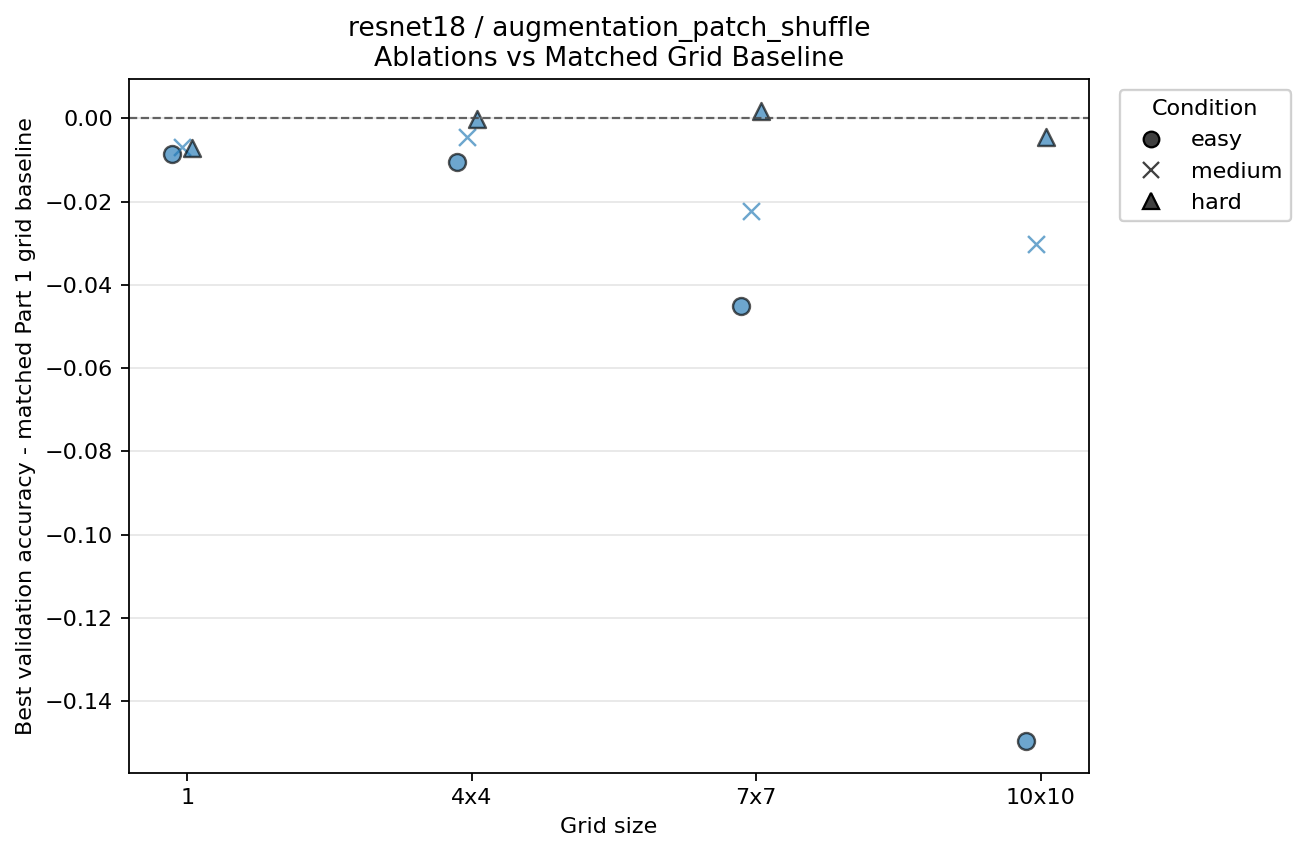


Running ablation: regular_augmentations

[1/12]
model=resnet18, ablation=regular_augmentations, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42/resnet18__regular_augmentations__tiles_1__perm_1__last.pt
Current run runtime: 6s
Total training runtime: 49s

[2/12]
model=resnet18, ablation=regular_augmentations, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. 

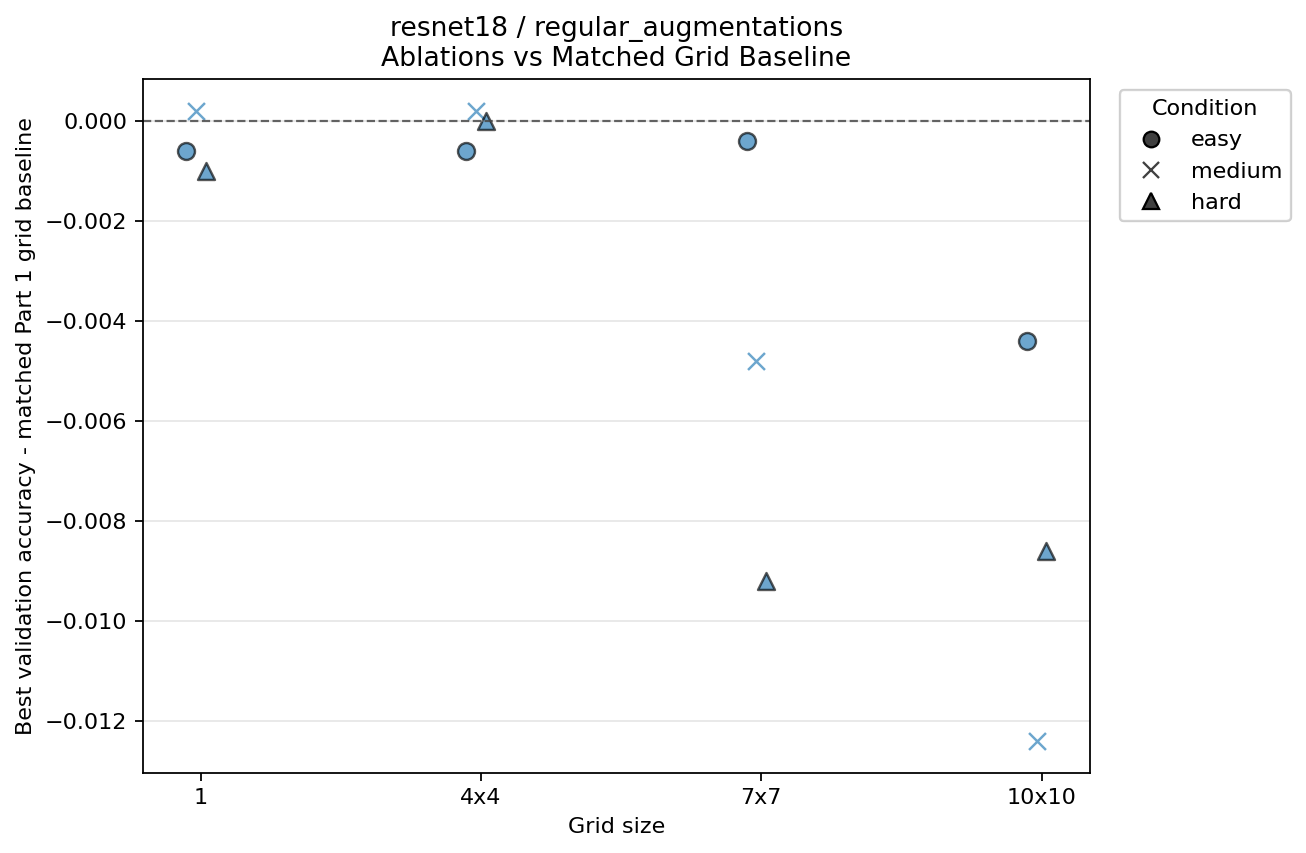


Running ablation: mixed_original_permuted

[1/12]
model=resnet18, ablation=mixed_original_permuted, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42/resnet18__mixed_original_permuted__tiles_1__perm_1__last.pt
Current run runtime: 3s
Total training runtime: 1m 26s

[2/12]
model=resnet18, ablation=mixed_original_permuted, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
s

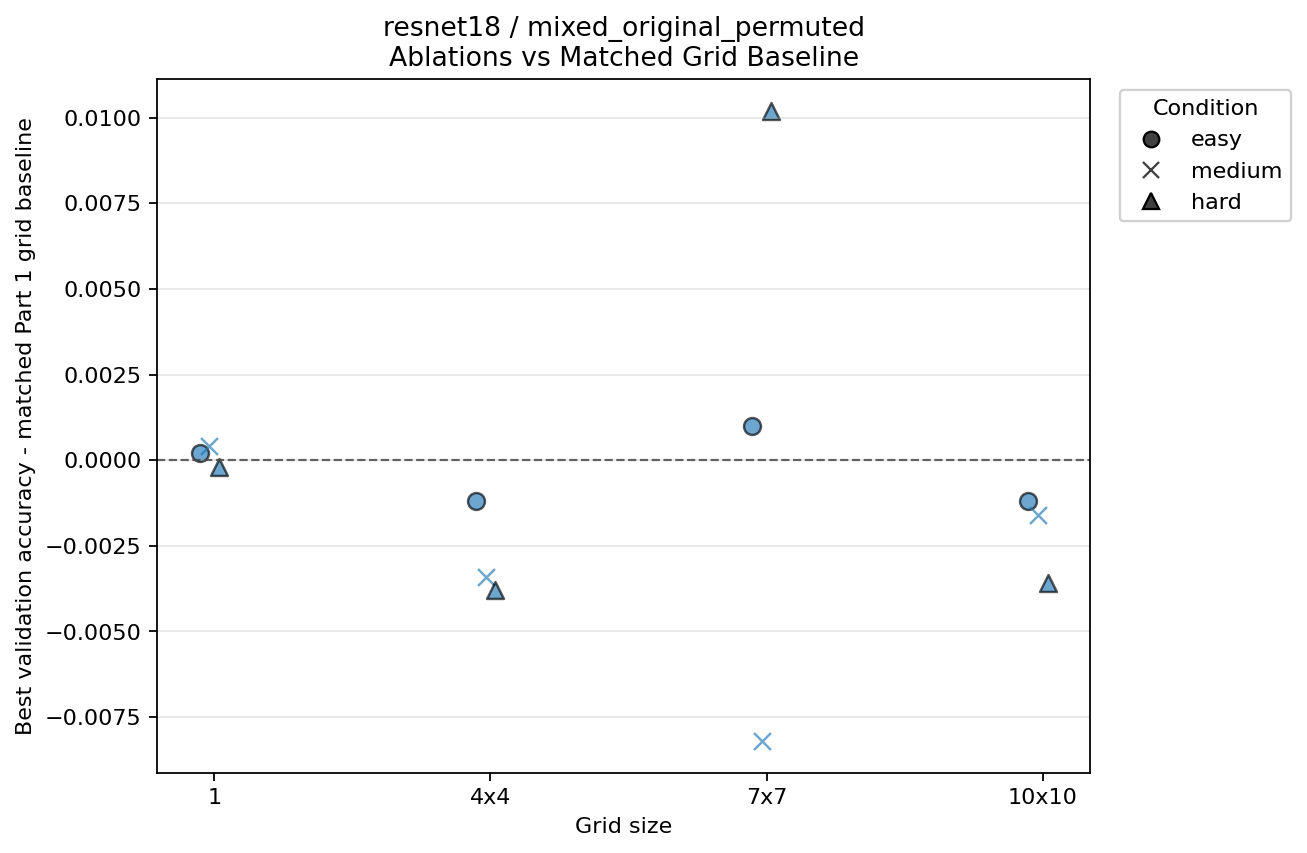


Running ablation: resnet18_mlp_head

[1/12]
model=resnet18, ablation=resnet18_mlp_head, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,308,866, trainable_params=132,354, optimizer_params=132,354, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42/resnet18__resnet18_mlp_head__tiles_1__perm_1__last.pt
Current run runtime: 4s
Total training runtime: 2m 07s

[2/12]
model=resnet18, ablation=resnet18_mlp_head, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard:

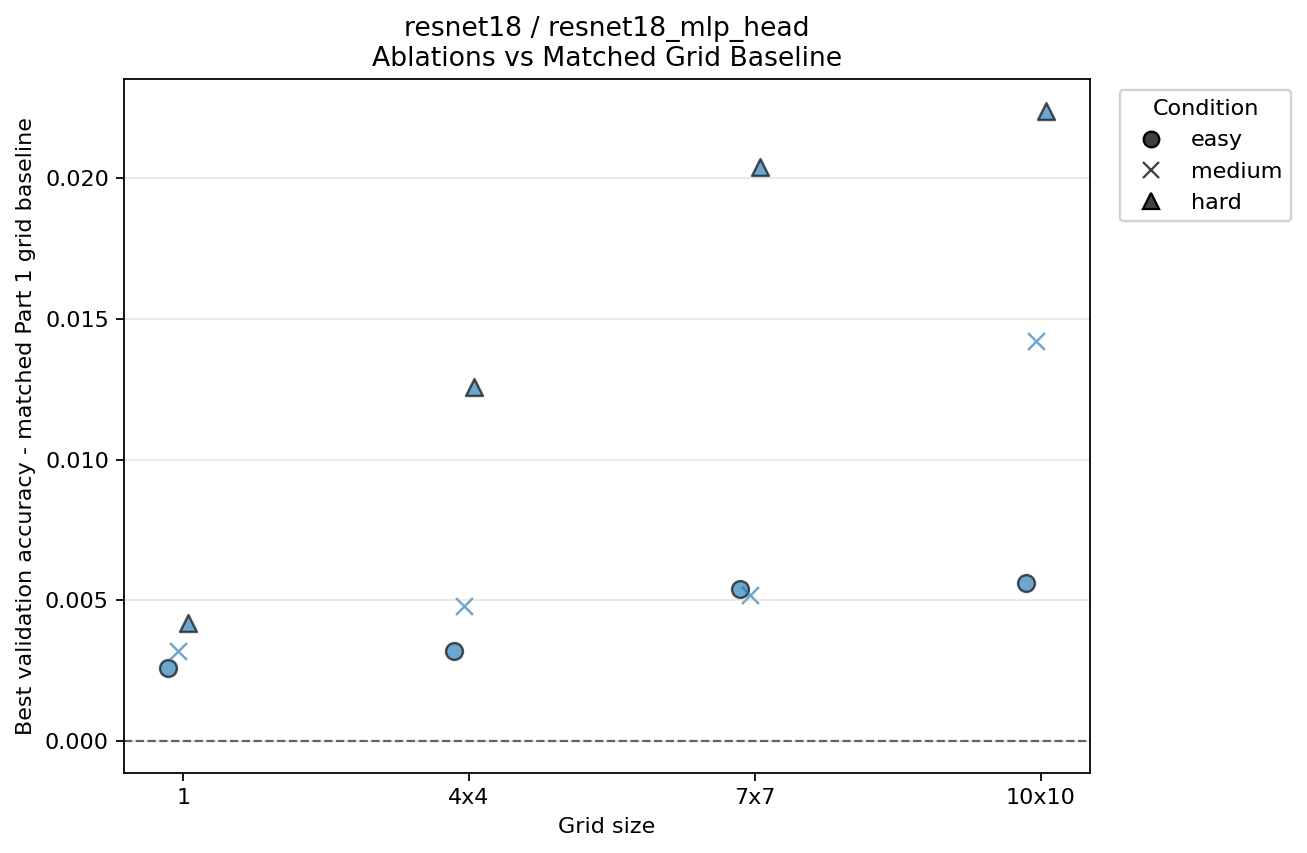


Running ablation: curriculum_corruption_probability

[1/12]
model=resnet18, ablation=curriculum_corruption_probability, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=4
1. permuted_probability_0.1: 8 epochs
	2. permuted_probability_0.3: 8 epochs
	3. permuted_probability_0.5: 7 epochs
	4. permuted_probability_0.8: 7 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Stage dataloaders: permuted_probability_0.1=20000 samples / 313 batches; permuted_probability_0.3=20000 samples / 313 batches; permuted_probability_0.5=20000 samples / 313 batches; permuted_probability_0.8=20000 samples / 313 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete;

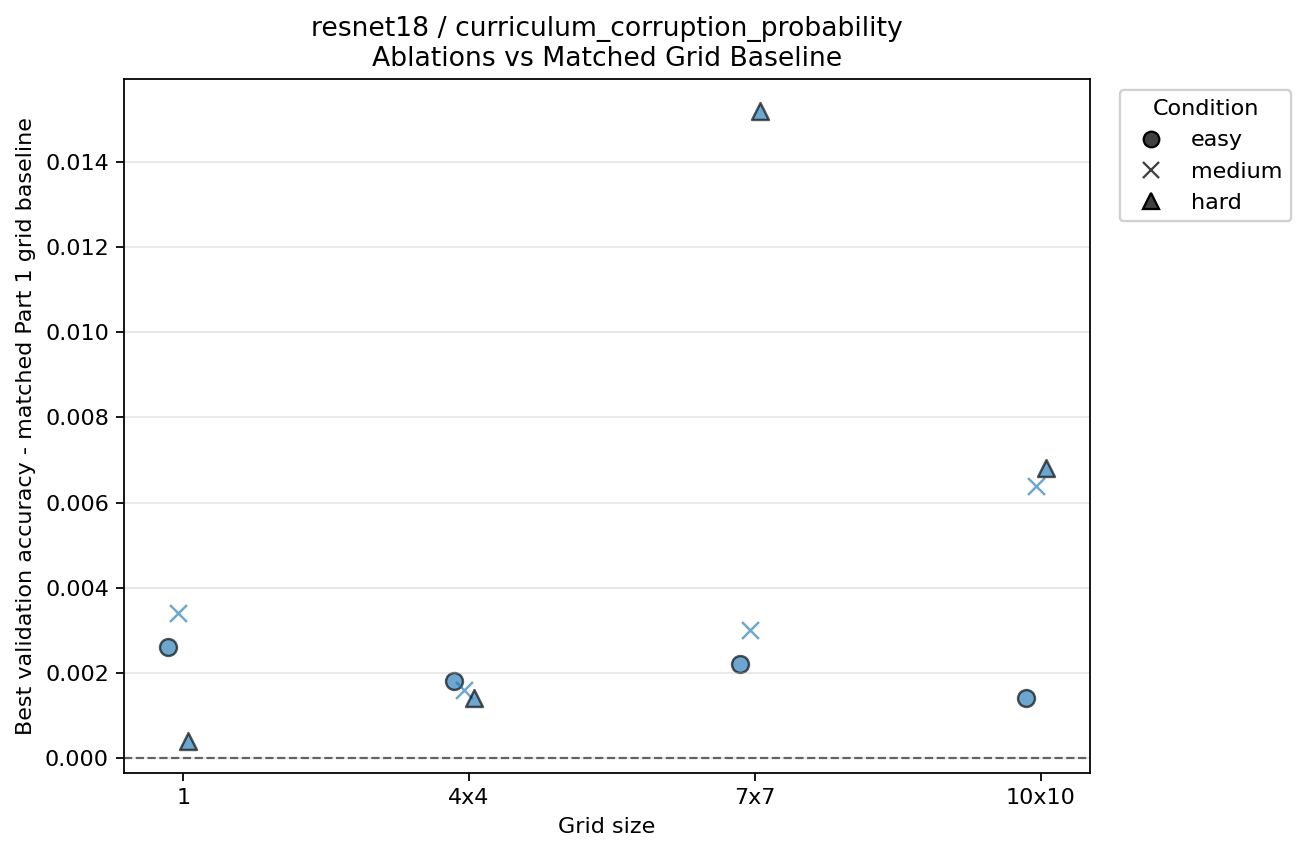


Running ablation: curriculum_permutation_difficulty

[1/12]
model=resnet18, ablation=curriculum_permutation_difficulty, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. original: 30 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Stage dataloaders: original=20000 samples / 313 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at epoch 30/30: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part2/part2_part2_improvement_seed_42/resnet18__curriculum_permutation_difficulty__tiles_1__perm_1__last.pt
Current run runtime: 3s
Total training runtime: 3m 10s

[2/12]
model=resnet18, ablation=curriculum_permutatio

resnet18 [curriculum_permutation_difficulty] 7x7 easy permutation. epochs progress:  93%|#########3| 28/30 [00…

resnet18 [curriculum_permutation_difficulty] 7x7 easy permutation. epochs progress epoch 29 batches:   0%|    …

resnet18 [curriculum_permutation_difficulty] 7x7 easy permutation. epochs progress epoch 30 batches:   0%|    …

Current run runtime: 3m 38s
Total training runtime: 7m 00s

[8/12]
model=resnet18, ablation=curriculum_permutation_difficulty, tiles_per_side=7, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=5
1. original: 6 epochs
	2. 2x2_permutation: 6 epochs
	3. 3x3_permutation: 6 epochs
	4. 4x4_permutation: 6 epochs
	5. 7x7_permutation: 6 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Stage dataloaders: original=20000 samples / 313 batches; 2x2_permutation=20000 samples / 313 batches; 3x3_permutation=20000 samples / 313 batches; 4x4_permutation=20000 samples / 313 batches; 7x7_permutation=20000 samples / 313 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
First batch: tensor_device

...

resnet18 [curriculum_permutation_difficulty] 10x10 hard permutation. epochs progress epoch 27 batches:   0%|  …

resnet18 [curriculum_permutation_difficulty] 10x10 hard permutation. epochs progress epoch 28 batches:   0%|  …

resnet18 [curriculum_permutation_difficulty] 10x10 hard permutation. epochs progress epoch 29 batches:   0%|  …

resnet18 [curriculum_permutation_difficulty] 10x10 hard permutation. epochs progress epoch 30 batches:   0%|  …

Current run runtime: 52m 06s
Total training runtime: 4h 24m 36s
Saved intermediate ablation plot: /content/drive/MyDrive/MLDS_Final_Project/outputs/figures/intermediate/part2_ablation_curriculum_permutation_difficulty.png


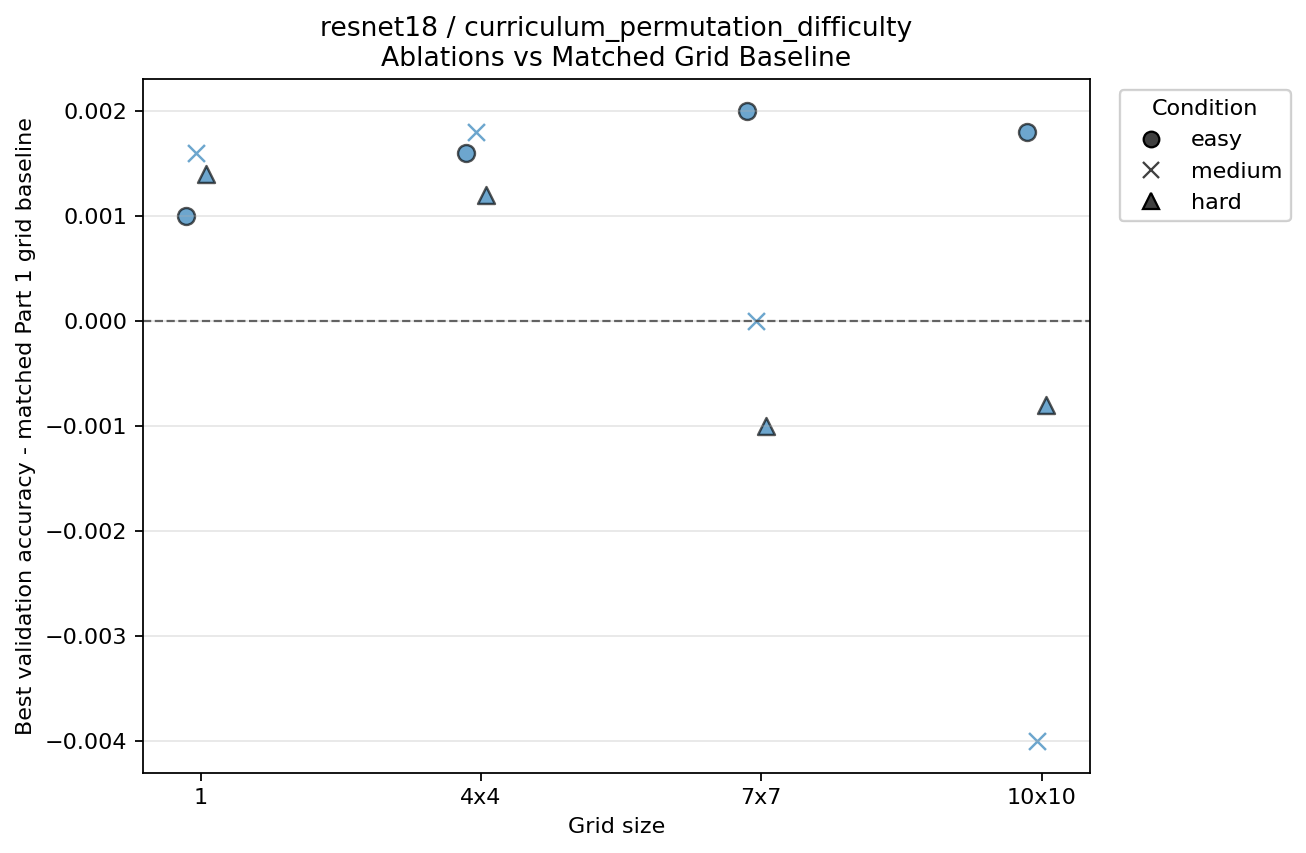

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,_grid_baseline_best_val_accuracy,delta_vs_grid_baseline
0,resnet18,augmentation_patch_shuffle,4.0,16,0.937067,0.026708,0.937333,0.026723,3,0.942467,-0.005133
1,resnet18,augmentation_patch_shuffle,7.0,49,0.888400,0.040463,0.894933,0.041223,3,0.916867,-0.021933
2,resnet18,augmentation_patch_shuffle,10.0,100,0.797000,0.027678,0.817200,0.014896,3,0.878667,-0.061467
3,resnet18,augmentation_patch_shuffle,NaN,1,0.970467,0.001155,0.971267,0.000611,3,0.978867,-0.007600
4,resnet18,curriculum_corruption_probability,4.0,16,0.943533,0.031605,0.944067,0.032106,3,0.942467,0.001600
5,resnet18,curriculum_corruption_probability,7.0,49,0.919267,0.061349,0.923667,0.057645,3,0.916867,0.006800
6,resnet18,curriculum_corruption_probability,10.0,100,0.881600,0.083469,0.883533,0.081723,3,0.878667,0.004867
7,resnet18,curriculum_corruption_probability,NaN,1,0.978733,0.003288,0.981000,0.001386,3,0.978867,0.002133
8,resnet18,curriculum_permutation_difficulty,4.0,16,0.942133,0.030901,0.944000,0.032112,3,0.942467,0.001533
9,resnet18,curriculum_permutation_difficulty,7.0,49,0.916867,0.065699,0.917200,0.065926,3,0.916867,0.000333


In [ ]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(
        config=config,
        device=device,
        intermediate_figure_callback=lambda path: display(Image(filename=str(path))),
    )
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')


## Enhanced Confidence Experiment
Run the reviewer-requested MobileNetV3-Small curriculum permutation-difficulty sweep. It uses the enhanced Part 1 MobileNet baseline as `regular_part1` and stores separate enhanced Part 2 outputs.


In [ ]:
%%time
RUN_ENHANCED_PART2 = True
part2_enhanced_output_paths = enhanced_confidence_output_paths(
    config.results_dir,
    config.figures_dir,
    'part2',
)

if RUN_ENHANCED_PART2:
    part2_enhanced_results = run_part2_enhanced_confidence_experiment(config, device=device)
    display(part2_enhanced_results)
else:
    enhanced_aggregated_path = Path(part2_enhanced_output_paths['aggregated_results'])
    if enhanced_aggregated_path.exists():
        part2_enhanced_results = pd.read_csv(enhanced_aggregated_path)
        display(part2_enhanced_results)
    else:
        print('Enhanced Part 2 results were not found. Set RUN_ENHANCED_PART2 = True to train missing runs.')

for figure_key in ['all_points_figure', 'mean_by_seed_figure']:
    figure_path = Path(part2_enhanced_output_paths[figure_key])
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print(f'Enhanced Part 2 figure not found yet: {figure_path}')


## Results

In [ ]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['tiles_per_side', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_patch_shuffle,4.0,16,0.937067,0.026708,0.937333,0.026723,3
4,resnet18,curriculum_corruption_probability,4.0,16,0.943533,0.031605,0.944067,0.032106,3
8,resnet18,curriculum_permutation_difficulty,4.0,16,0.942133,0.030901,0.944000,0.032112,3
12,resnet18,mixed_original_permuted,4.0,16,0.938667,0.033239,0.939667,0.033200,3
16,resnet18,regular_augmentations,4.0,16,0.940667,0.031551,0.942333,0.031613,3
20,resnet18,regular_part1,4.0,16,0.942333,0.031903,0.942467,0.031906,3
24,resnet18,resnet18_mlp_head,4.0,16,0.946533,0.030200,0.949333,0.027224,3
1,resnet18,augmentation_patch_shuffle,7.0,49,0.888400,0.040463,0.894933,0.041223,3
5,resnet18,curriculum_corruption_probability,7.0,49,0.919267,0.061349,0.923667,0.057645,3
9,resnet18,curriculum_permutation_difficulty,7.0,49,0.916867,0.065699,0.917200,0.065926,3


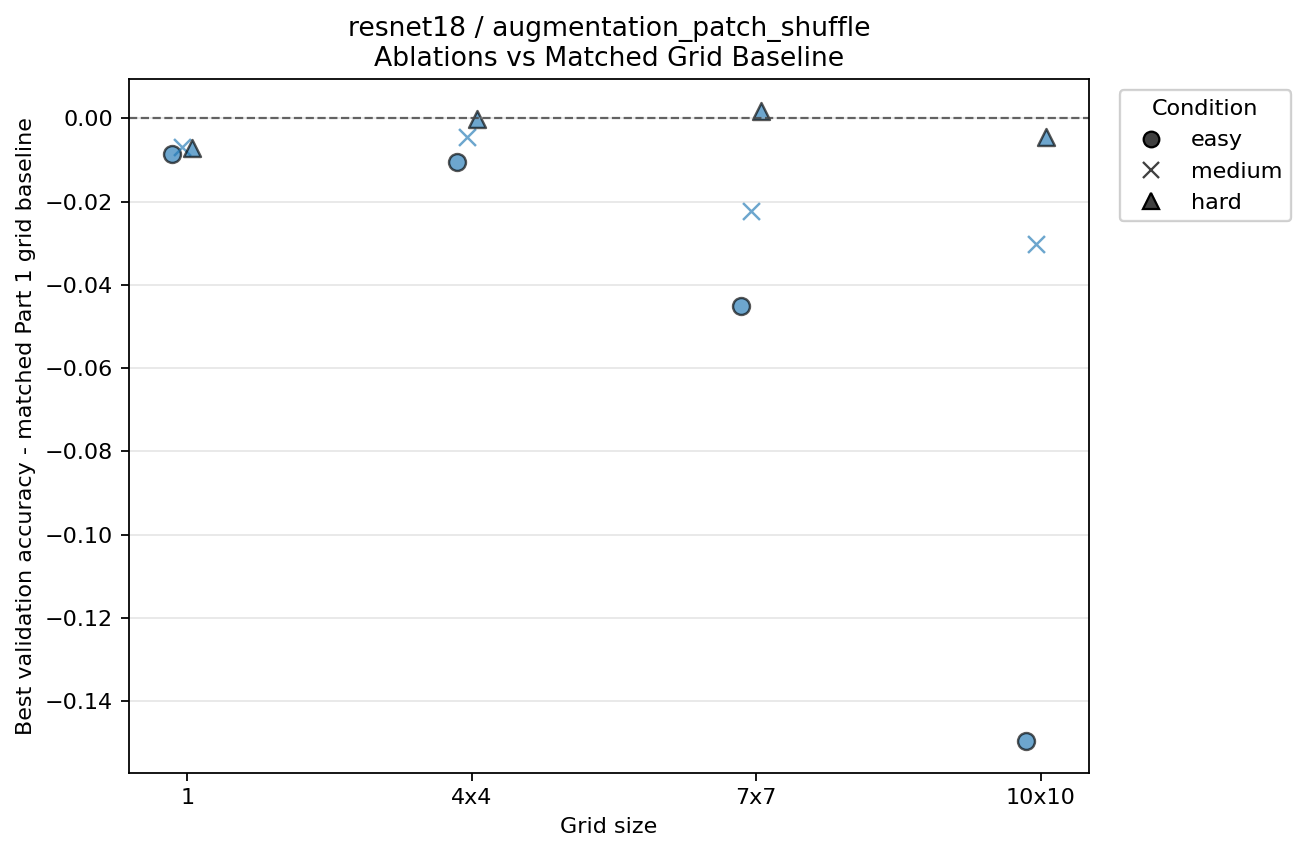

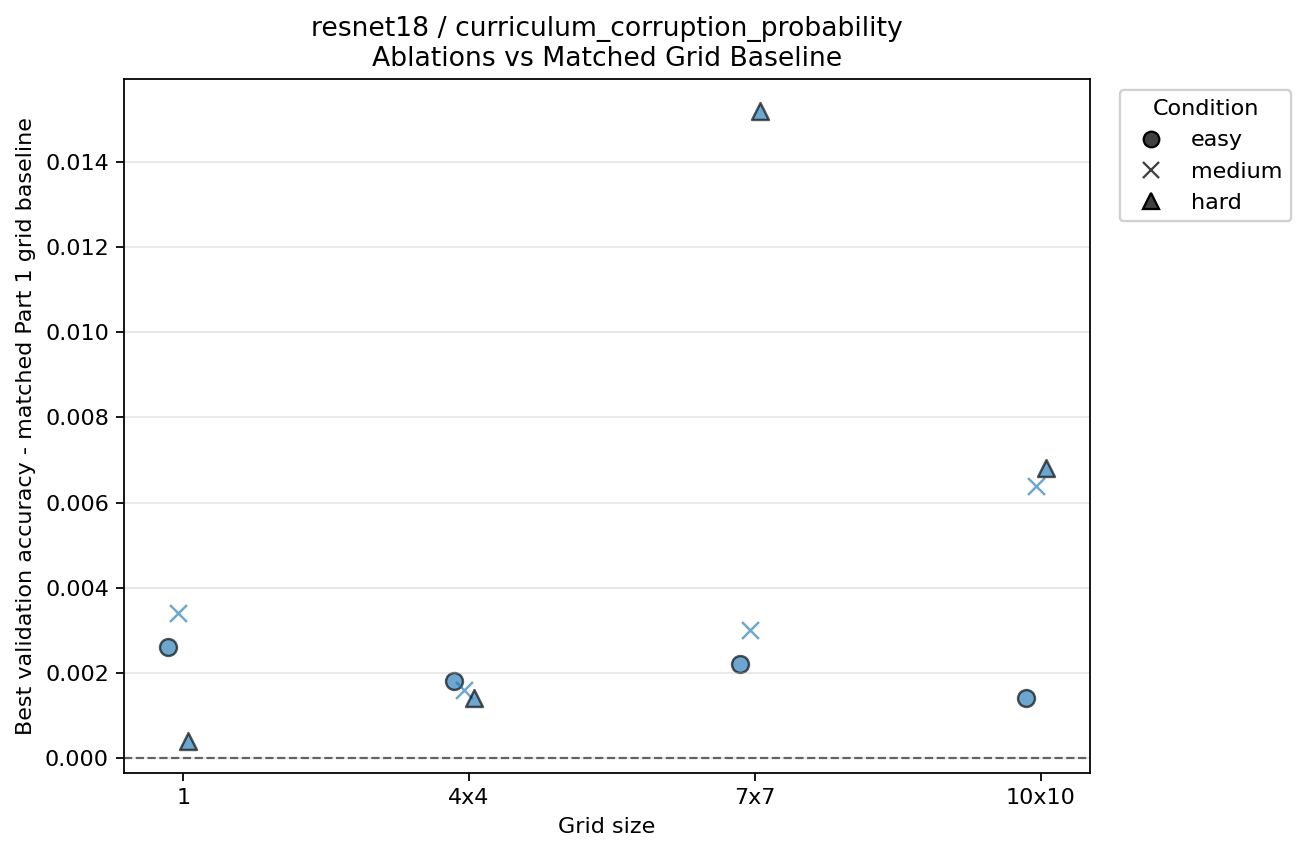

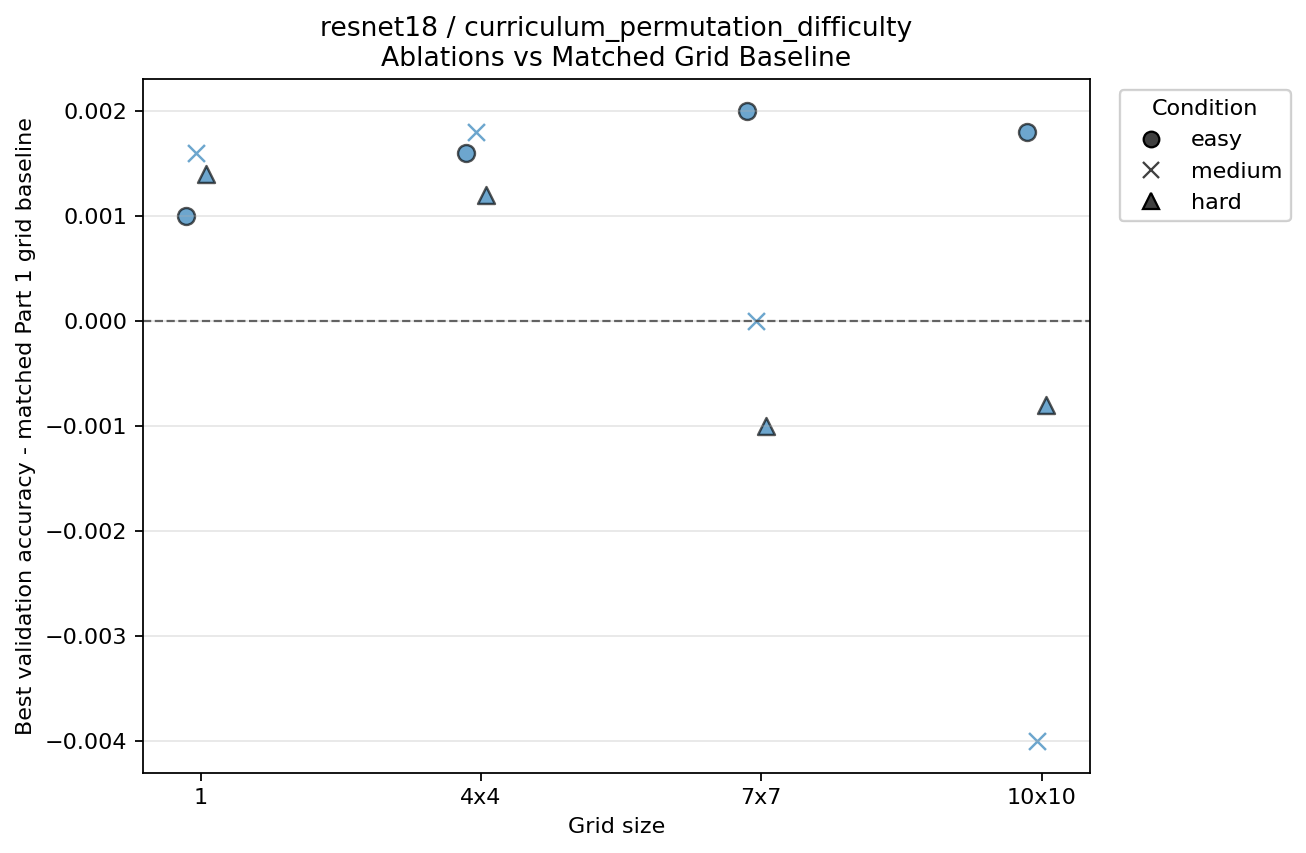

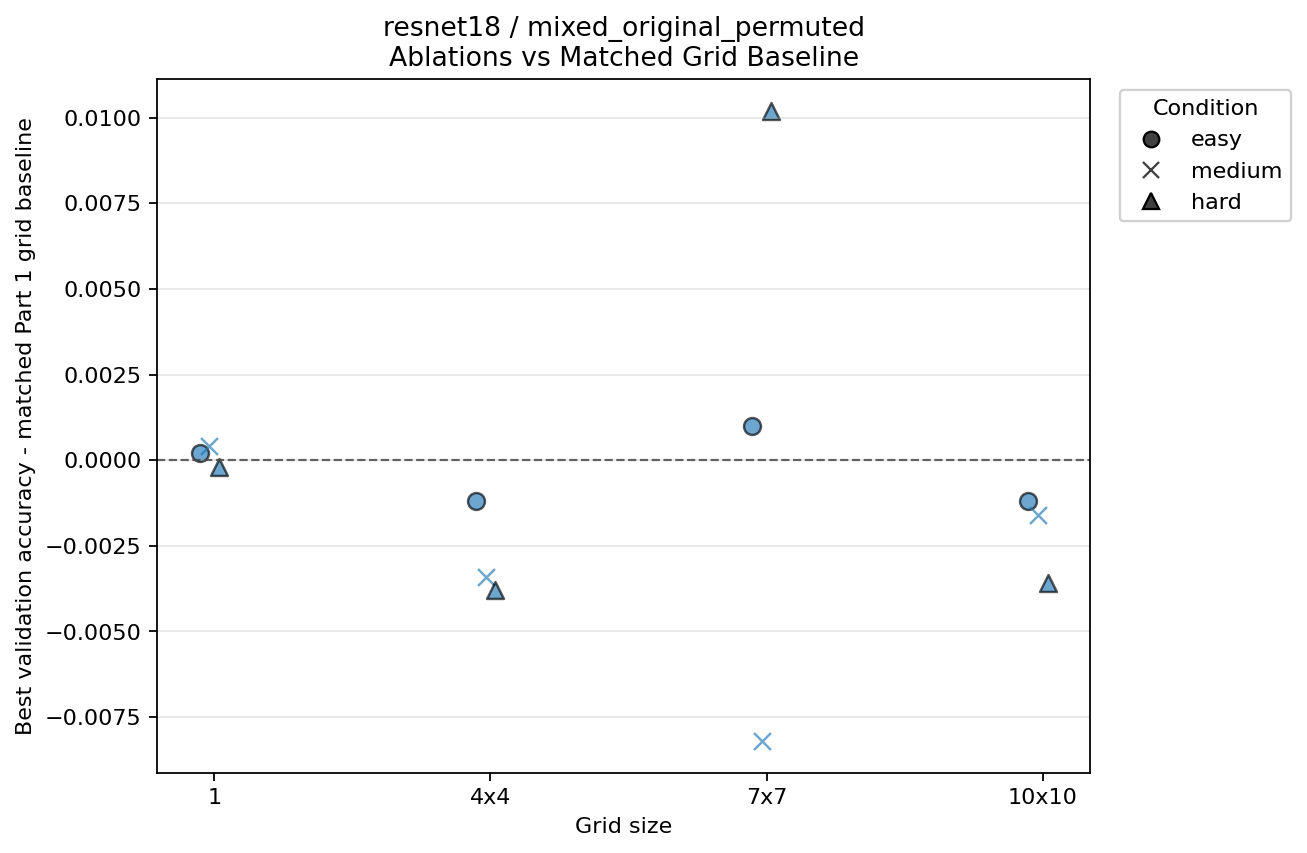

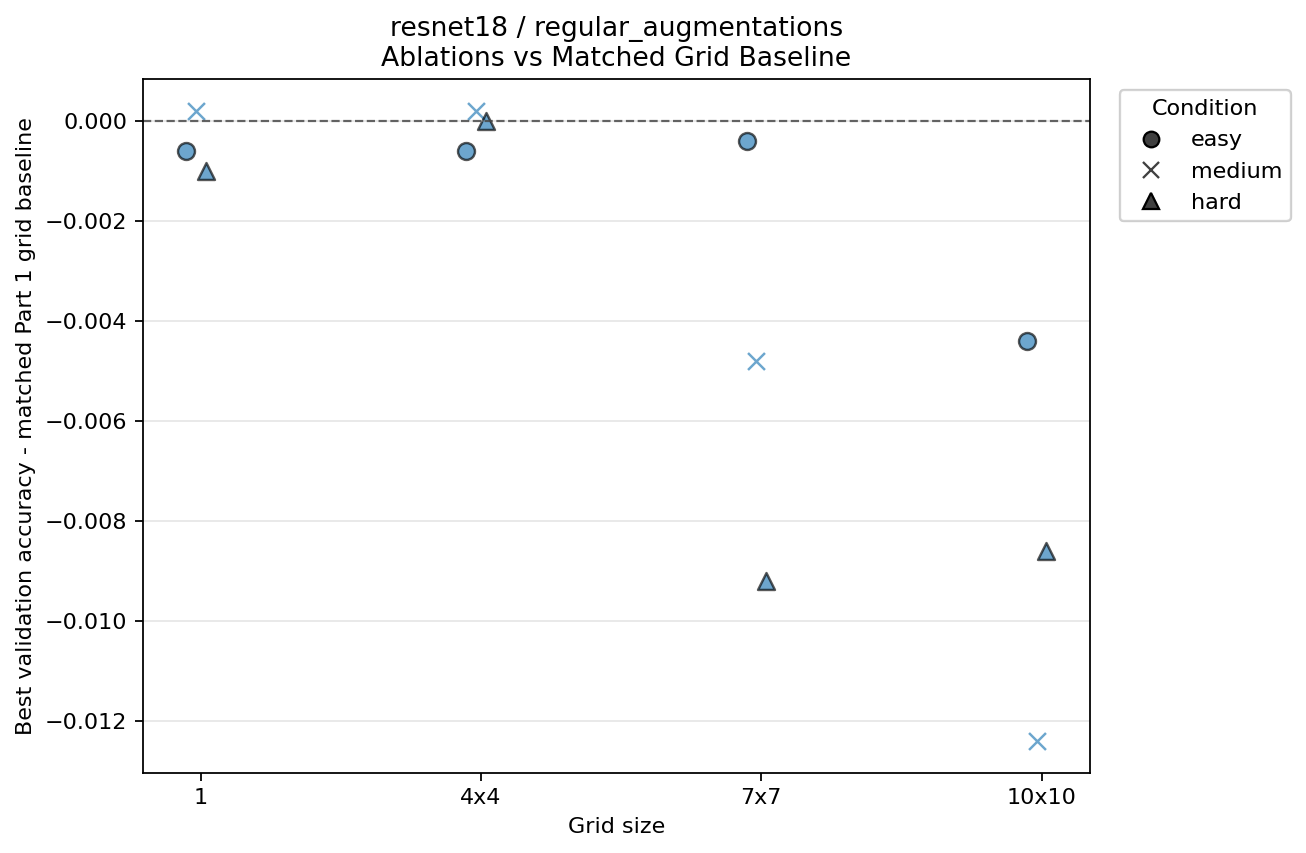

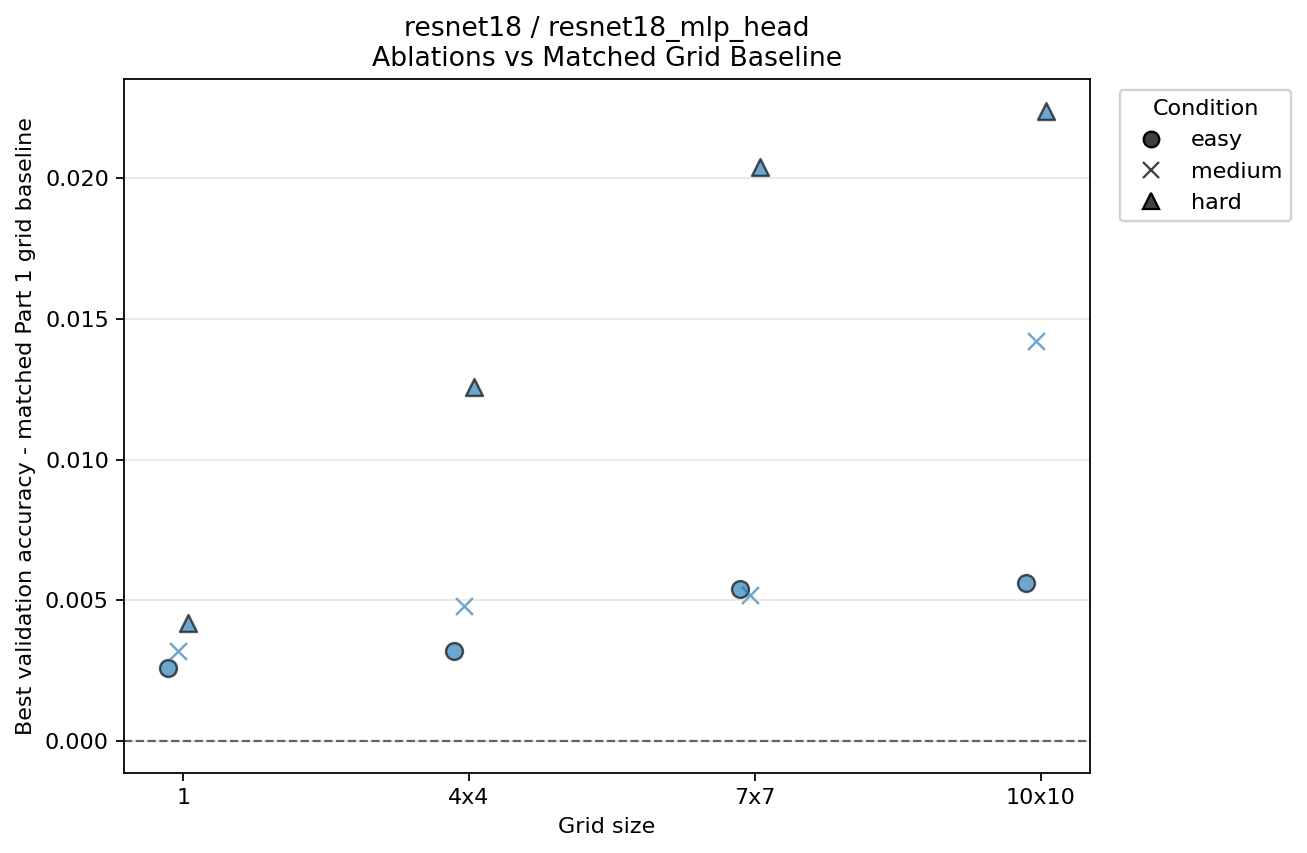

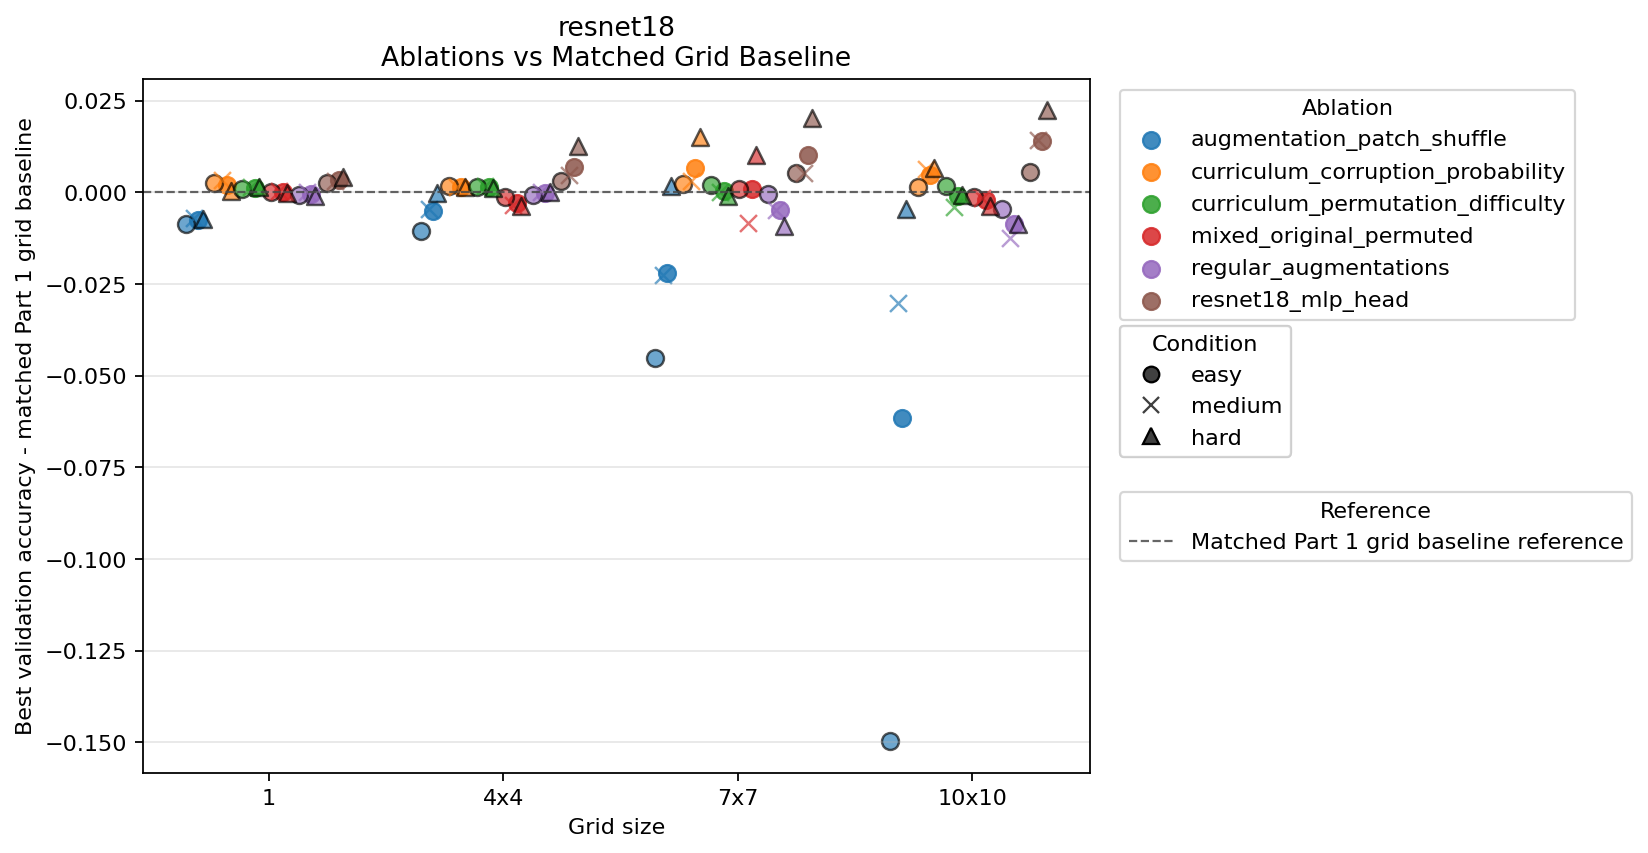

In [2]:
import src.utils.results_overview as results_overview

intermediate_dir = Path(output_paths['intermediate_figures_dir'])
for figure_path in results_overview.latest_intermediate_figures(intermediate_dir, prefix='part2_'):
    display(Image(filename=str(figure_path)))

figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')


In [ ]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import importlib

import src.utils.notebook_setup as notebook_setup

notebook_setup = importlib.reload(notebook_setup)
notebook_path = ROOT / 'src' / 'notebooks' / 'part2_solution.ipynb'
export_dir = ROOT / 'outputs' / 'notebooks'
notebook_setup.export_notebook_to_pdf(notebook_path, export_dir)
